In [1]:
from dotenv import load_dotenv
from pathlib import Path
import sys
import os

# Walk up until we find the project root (folder with the .env)
current_path = Path().resolve()
for parent in [current_path] + list(current_path.parents):
    if (parent / ".env").exists():
        load_dotenv(parent / ".env")
        project_root = os.getenv("PROJECT_ROOT")
        print(project_root)
        sys.path.append(project_root)     
        break


%load_ext autoreload
%autoreload 2

/mnt/home/test/beluga-call-pipeline/


In [2]:
import pandas as pd
from pathlib import Path

dir = "../results/optimization/mobile_net_12_layers/"

# Loop through all folds and collect DataFrames
all_predictions = []
for fold_num in range(5):
    fold_path = Path(dir) / f"fold_{fold_num}" / "test_predictions.csv"
    fold_df = pd.read_csv(fold_path)
    all_predictions.append(fold_df)

# Merge all predictions into one DataFrame
test_predictions_df = pd.concat(all_predictions, ignore_index=True)
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold
0,BSM_20170724_10580300.pt,BSM,0.0,0.0,1.064708e-07,0.0,0.0,5.555425e-08,0.0,0.0,8.210722e-10,0.0,0.0,7.577163e-04,0
1,BSM_20170724_12500100.pt,BSM,0.0,0.0,5.124426e-10,0.0,0.0,4.828254e-13,0.0,0.0,2.277526e-15,0.0,0.0,4.426653e-12,0
2,BSM_20170724_13091179.pt,BSM,0.0,0.0,9.881670e-08,0.0,0.0,2.271912e-07,0.0,0.0,2.599865e-08,1.0,1.0,9.998454e-01,0
3,BSM_20170724_13182240.pt,BSM,1.0,1.0,9.999999e-01,0.0,0.0,9.292549e-09,0.0,0.0,2.737549e-11,0.0,0.0,2.100043e-07,0
4,BSM_20170724_13215300.pt,BSM,0.0,0.0,1.022840e-11,0.0,0.0,4.166788e-14,0.0,0.0,2.764440e-15,0.0,0.0,8.305502e-12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15513,RDL_20200828_18463981.pt,RDL,0.0,0.0,1.296506e-03,0.0,0.0,4.369019e-05,1.0,1.0,9.999999e-01,1.0,1.0,9.997057e-01,4
15514,RDL_20200828_18471243.pt,RDL,0.0,0.0,1.048050e-01,1.0,0.0,3.967041e-01,1.0,1.0,9.999752e-01,1.0,1.0,9.975997e-01,4
15515,RDL_20200828_18472532.pt,RDL,0.0,0.0,3.582016e-06,1.0,0.0,5.182538e-04,1.0,1.0,9.999506e-01,1.0,1.0,9.909115e-01,4
15516,RDL_20200829_13033400.pt,RDL,0.0,0.0,1.274915e-05,0.0,0.0,1.400412e-09,0.0,0.0,1.158168e-10,0.0,0.0,3.644869e-10,4


In [3]:
import pandas as pd
labels_df = pd.read_csv("../../data/Verified_Dataset/labels/labels_merged.csv")
labels_df["ClipFilenamePt"] = labels_df["clip_filename"].str.replace(".wav", ".pt", regex=False)

merged_df = test_predictions_df.merge(
    labels_df[["ClipFilenamePt", "Boat", "HydrophoneSensitivity", "labeling_effort", "original_filename", "labeled_snippet_filename", "Begin Time (s)"]],
    how="left",
    left_on="Filename",
    right_on="ClipFilenamePt"
)
test_predictions_df = merged_df.drop(columns=["ClipFilenamePt"])


In [4]:
test_predictions_df["AnyCall_pred"] = test_predictions_df[["ECHO_pred", "HFPC_pred", "BBPC_pred", "Whistle_pred"]].any(axis=1)
test_predictions_df["AnyCall_true"] = test_predictions_df[["ECHO_true", "HFPC_true", "BBPC_true", "Whistle_true"]].any(axis=1)



In [5]:
pd.set_option('display.max_columns', None)
test_predictions_df.head(2)

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,Begin Time (s),AnyCall_pred,AnyCall_true
0,BSM_20170724_10580300.pt,BSM,0.0,0.0,1.064708e-07,0.0,0.0,5.555425e-08,0.0,0.0,8.210722e-10,0.0,0.0,7.577163e-04,0,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
1,BSM_20170724_12500100.pt,BSM,0.0,0.0,5.124426e-10,0.0,0.0,4.828254e-13,0.0,0.0,2.277526e-15,0.0,0.0,4.426653e-12,0,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False


In [6]:
from sklearn.metrics import multilabel_confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# =============================================================================
# Configuration
# =============================================================================



# =============================================================================
# Core Metrics Functions
# =============================================================================
def get_multilabel_metrics(df, call_types, true_suffix="_true", pred_suffix="_pred"):
    """
    Get multilabel metrics and confusion matrices for a dataframe subset.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing predictions and ground truth
    call_types : list
        List of call type names
    subset_name : str
        Name for this subset (e.g., "Overall", "KAM_2020", "boat_passage")
        
    Returns:
    --------
    dict
        Dictionary containing metrics, confusion matrices, and metadata
    """
    if len(df) == 0:
        return None
        
    y_true = df[[f"{c}{true_suffix}" for c in call_types]].astype(int).values
    y_pred = df[[f"{c}{pred_suffix}" for c in call_types]].astype(int).values
    
    # Get classification report
    report = classification_report(
        y_true, 
        y_pred, 
        target_names=call_types, 
        output_dict=True, 
        zero_division=0
    )
    
    # Get confusion matrices
    mcm_array = multilabel_confusion_matrix(y_true, y_pred)
    mcm = {call_type: mcm_array[i] for i, call_type in enumerate(call_types)}
    # Calculate false alarm rate for each class
    # mcm shape: (n_classes, 2, 2) where each 2x2 matrix is [[TN, FP], [FN, TP]]
    false_alarm_rates = {}
    for call_type in call_types:
        tn, fp = mcm[call_type][0, 0], mcm[call_type][0, 1]
        # False Alarm Rate = FP / (FP + TN), avoid division by zero
        far = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        report[call_type]["false_alarm_rate"] = far
    
    return {
        'report': report,
        'mcm': mcm,
        'false_alarm_rates': false_alarm_rates,
        'y_true': y_true,
        'y_pred': y_pred,
        'n_samples': len(df)
    }


def compute_metrics_by_grouping(df, call_types, group_by=None):
    """
    Compute metrics for overall data and by grouping variable.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame containing predictions and ground truth
    call_types : list
        List of call type names
    group_by : str or None
        Column name to group by (e.g., 'context', 'site', or None for overall only)
        
    Returns:
    --------
    tuple
        (metrics_overall, metrics_by_group) where metrics_by_group is a dict
    """
    # Overall metrics
    metrics_overall = get_multilabel_metrics(df, call_types)
    metrics_overall["name"] = "Overall"
    
    # Group-specific metrics
    metrics_by_group = {}
    if group_by and group_by in df.columns:
        unique_groups = df[group_by].unique()
        for group in unique_groups:
            df_group = df[df[group_by] == group]
            if len(df_group) > 0:
                metrics_by_group[group] = get_multilabel_metrics(df_group, call_types)
                metrics_by_group[group]["name"] = str(group)
    
    
    return metrics_overall, metrics_by_group


def create_summary_dataframe(metrics_overall, metrics_by_group, call_types, group_name="Group"):
    """
    Create a summary dataframe from computed metrics.
    
    Parameters:
    -----------
    metrics_overall : dict
        Overall metrics dictionary
    metrics_by_group : dict
        Dictionary of metrics by group
    call_types : list
        List of call type names
    group_name : str
        Name for the grouping column (e.g., "Context", "Site")
        
    Returns:
    --------
    pd.DataFrame
        Summary dataframe with metrics for all call types and groups
    """
    summary_data = []
    
    for call in call_types:
        # Overall
        if metrics_overall:
            summary_data.append({
                'Call Type': call,
                group_name: 'Overall',
                'Precision': metrics_overall['report'][call]['precision'],
                'Recall': metrics_overall['report'][call]['recall'],
                'F1-Score': metrics_overall['report'][call]['f1-score'],
                'False Alarm Rate': metrics_overall['report'][call]['false_alarm_rate'],
                'Support': int(metrics_overall['report'][call]['support'])
            })
        
        # By group
        for group_key, metrics in metrics_by_group.items():
            if metrics:
                summary_data.append({
                    'Call Type': call,
                    group_name: group_key,
                    'Precision': metrics['report'][call]['precision'],
                    'Recall': metrics['report'][call]['recall'],
                    'F1-Score': metrics['report'][call]['f1-score'],
                    'False Alarm Rate': metrics['report'][call]['false_alarm_rate'],
                    'Support': int(metrics['report'][call]['support'])
                })
    
    return pd.DataFrame(summary_data)


def create_average_metrics_dataframe(metrics_overall, metrics_by_group, group_name="Group"):
    """
    Create dataframe with averaged metrics across all call types.
    
    Parameters:
    -----------
    metrics_overall : dict
        Overall metrics dictionary
    metrics_by_group : dict
        Dictionary of metrics by group
    group_name : str
        Name for the grouping column
        
    Returns:
    --------
    pd.DataFrame
        Dataframe with macro/micro/samples averages
    """
    avg_metrics = []
    
    # Overall
    if metrics_overall:
        report = metrics_overall['report']
        avg_metrics.append({
            group_name: 'Overall',
            'Macro Avg Precision': report['macro avg']['precision'],
            'Macro Avg Recall': report['macro avg']['recall'],
            'Macro Avg F1': report['macro avg']['f1-score'],
            'Micro Avg F1': report['micro avg']['f1-score'],
            'False Alarm Rate': metrics_overall['false_alarm_rates'],
            'Samples Avg F1': report['samples avg']['f1-score'],
            'n_samples': metrics_overall['n_samples']
        })
    
    # By group
    for group_key, metrics in metrics_by_group.items():
        if metrics:
            report = metrics['report']
            avg_metrics.append({
                group_name: group_key,
                'Macro Avg Precision': report['macro avg']['precision'],
                'Macro Avg Recall': report['macro avg']['recall'],
                'Macro Avg F1': report['macro avg']['f1-score'],
                'Micro Avg F1': report['micro avg']['f1-score'],
                'False Alarm Rate': metrics['false_alarm_rates'],
                'Samples Avg F1': report['samples avg']['f1-score'],
                'n_samples': metrics['n_samples']
            })
    
    return pd.DataFrame(avg_metrics)


def plot_metrics_comparison(summary_df, group_name="Group", exclude_overall=True, figsize=(14, 10)):
    """
    Create bar plots comparing metrics across call types and groups.
    
    Parameters:
    -----------
    summary_df : pd.DataFrame
        Summary dataframe with metrics
    group_name : str
        Name of the grouping column
    exclude_overall : bool
        Whether to exclude 'Overall' from visualization
    figsize : tuple
        Figure size
        
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure
    """
    # Filter data
    plot_df = summary_df.copy()
    if exclude_overall:
        plot_df = plot_df[plot_df[group_name] != 'Overall']
    
    if len(plot_df) == 0:
        print("No data to plot after filtering")
        return None
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    metrics_to_plot = ['Precision', 'Recall', 'F1-Score', 'Support']
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx // 2, idx % 2]
        
        # Pivot data for plotting
        pivot_data = plot_df.pivot(index='Call Type', columns=group_name, values=metric)
        
        pivot_data.plot(kind='bar', ax=ax, rot=0)
        ax.set_title(f'{metric} by Call Type and {group_name}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Call Type')
        ax.set_ylabel(metric)
        ax.legend(title=group_name, loc='best')
        ax.grid(axis='y', alpha=0.3)
        
        # Set y-limit only for percentage metrics
        if metric in ['Precision', 'Recall', 'F1-Score']:
            ax.set_ylim([0, 1.0])
    
    plt.tight_layout()
    return fig


def print_classification_report(metrics_overall, call_types):
    """Print formatted classification report."""
    if metrics_overall:
        print(f"\n{'='*80}")
        print("OVERALL CLASSIFICATION REPORT")
        print(f"{'='*80}\n")
        print(classification_report(
            metrics_overall['y_true'], 
            metrics_overall['y_pred'], 
            target_names=call_types, 
            zero_division=0
        ))


def print_summary_table(summary_df, group_name="Group"):
    """Print formatted summary table."""
    print(f"\n\n{'='*80}")
    print(f"SUMMARY TABLE: All Call Types by {group_name}")
    print(f"{'='*80}\n")
    print(summary_df.to_string(index=False))


def print_average_metrics(avg_df, group_name="Group"):
    """Print formatted average metrics table."""
    print(f"\n\n{'='*80}")
    print(f"AVERAGE METRICS ACROSS ALL CALL TYPES BY {group_name}")
    print(f"{'='*80}\n")
    print(avg_df.to_string(index=False))

In [7]:
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,Begin Time (s),AnyCall_pred,AnyCall_true
0,BSM_20170724_10580300.pt,BSM,0.0,0.0,1.064708e-07,0.0,0.0,5.555425e-08,0.0,0.0,8.210722e-10,0.0,0.0,7.577163e-04,0,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
1,BSM_20170724_12500100.pt,BSM,0.0,0.0,5.124426e-10,0.0,0.0,4.828254e-13,0.0,0.0,2.277526e-15,0.0,0.0,4.426653e-12,0,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
2,BSM_20170724_13091179.pt,BSM,0.0,0.0,9.881670e-08,0.0,0.0,2.271912e-07,0.0,0.0,2.599865e-08,1.0,1.0,9.998454e-01,0,0.0,-172.7,irene_20min,NaN,NaN,NaN,True,True
3,BSM_20170724_13182240.pt,BSM,1.0,1.0,9.999999e-01,0.0,0.0,9.292549e-09,0.0,0.0,2.737549e-11,0.0,0.0,2.100043e-07,0,0.0,-172.7,irene_20min,NaN,NaN,NaN,True,True
4,BSM_20170724_13215300.pt,BSM,0.0,0.0,1.022840e-11,0.0,0.0,4.166788e-14,0.0,0.0,2.764440e-15,0.0,0.0,8.305502e-12,0,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15513,RDL_20200828_18463981.pt,RDL,0.0,0.0,1.296506e-03,0.0,0.0,4.369019e-05,1.0,1.0,9.999999e-01,1.0,1.0,9.997057e-01,4,1.0,-176.5,irene_5min,NaN,NaN,NaN,True,True
15514,RDL_20200828_18471243.pt,RDL,0.0,0.0,1.048050e-01,1.0,0.0,3.967041e-01,1.0,1.0,9.999752e-01,1.0,1.0,9.975997e-01,4,0.0,-176.5,irene_20min,NaN,NaN,NaN,True,True
15515,RDL_20200828_18472532.pt,RDL,0.0,0.0,3.582016e-06,1.0,0.0,5.182538e-04,1.0,1.0,9.999506e-01,1.0,1.0,9.909115e-01,4,0.0,-176.5,irene_20min,NaN,NaN,NaN,True,True
15516,RDL_20200829_13033400.pt,RDL,0.0,0.0,1.274915e-05,0.0,0.0,1.400412e-09,0.0,0.0,1.158168e-10,0.0,0.0,3.644869e-10,4,0.0,-176.5,irene_20min,NaN,NaN,NaN,False,False


In [8]:
# =============================================================================
# ANALYSIS BY CONTEXT
# =============================================================================
print("="*80)
print("ANALYSIS BY CONTEXT")
print("="*80)
call_types = ["ECHO", "BBPC", "HFPC", "Whistle"] + ["AnyCall"]


# test_predictions_df["Boat"] = test_predictions_df["Boat"].fillna(0)

# Compute metrics
metrics_overall, metrics_by_context = compute_metrics_by_grouping(
    test_predictions_df, call_types, group_by='Boat'
)
# metrics_overall, metrics_by_context = compute_metrics_by_grouping(
#     test_predictions_df, ["AnyCall"], group_by='labeled_snippet_filename'
# )
# Print reports
print_classification_report(metrics_overall, call_types)


ANALYSIS BY CONTEXT

OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.94      0.89      0.92      5289
        BBPC       0.85      0.80      0.82       984
        HFPC       0.87      0.85      0.86       792
     Whistle       0.89      0.86      0.87      2917
     AnyCall       0.96      0.93      0.95      6660

   micro avg       0.93      0.90      0.91     16642
   macro avg       0.90      0.87      0.88     16642
weighted avg       0.93      0.90      0.91     16642
 samples avg       0.39      0.38      0.38     16642



In [9]:
metrics_by_context

{np.float64(0.0): {'report': {'ECHO': {'precision': 0.9472830494728305,
    'recall': 0.8888888888888888,
    'f1-score': 0.917157440125638,
    'support': 2628.0,
    'false_alarm_rate': np.float64(0.07514450867052024)},
   'BBPC': {'precision': 0.8877146631439894,
    'recall': 0.8225214198286414,
    'f1-score': 0.8538754764930114,
    'support': 817.0,
    'false_alarm_rate': np.float64(0.024004518497599547)},
   'HFPC': {'precision': 0.8818493150684932,
    'recall': 0.8925476603119584,
    'f1-score': 0.8871662360034454,
    'support': 577.0,
    'false_alarm_rate': np.float64(0.018249140439037293)},
   'Whistle': {'precision': 0.8973458235753318,
    'recall': 0.9026305457400864,
    'f1-score': 0.899980426697984,
    'support': 2547.0,
    'false_alarm_rate': np.float64(0.14522363335173938)},
   'AnyCall': {'precision': 0.9811117107393416,
    'recall': 0.9488517745302714,
    'f1-score': 0.9647121252321571,
    'support': 3832.0,
    'false_alarm_rate': np.float64(0.1330798479

In [10]:
# Get top 10 keys with the lowest report.Whistle.recall
import numpy as np

# Build a list of (key, recall) tuples, handling missing cases robustly
key_recall = []
for k, v in metrics_by_context.items():
    try:
        recall = v["report"]["Whistle"].get("recall", np.nan)
        support = v["report"]["Whistle"].get("support", np.nan)
    except Exception:
        recall = np.nan
    if support > 3:
        key_recall.append((k, recall))

# Sort by recall (ascending), NaNs to the end
key_recall_sorted = sorted(key_recall, key=lambda x: (np.isnan(x[1]), x[1]))

# Get top 10
top10_lowest = key_recall_sorted[:10]

print("Top 10 keys with lowest report.Whistle.recall:")
for k, r in top10_lowest:
    metrics_by_context[k]
    print(k)
    # print(metrics_by_context[k]["report"])
    print_classification_report(metrics_by_context[k], call_types)

Top 10 keys with lowest report.Whistle.recall:
1.0

OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.94      0.90      0.92      2661
        BBPC       0.66      0.69      0.68       167
        HFPC       0.83      0.74      0.79       215
     Whistle       0.87      0.54      0.67       370
     AnyCall       0.95      0.91      0.93      2828

   micro avg       0.93      0.87      0.90      6241
   macro avg       0.85      0.76      0.80      6241
weighted avg       0.93      0.87      0.90      6241
 samples avg       0.58      0.57      0.58      6241

0.0

OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.95      0.89      0.92      2628
        BBPC       0.89      0.82      0.85       817
        HFPC       0.88      0.89      0.89       577
     Whistle       0.90      0.90      0.90      2547
     AnyCall       0.98      0.95      0.96      3832

   micro avg

In [11]:

print_classification_report(metrics_by_context[0], call_types)
print_classification_report(metrics_by_context[1], call_types)


OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.95      0.89      0.92      2628
        BBPC       0.89      0.82      0.85       817
        HFPC       0.88      0.89      0.89       577
     Whistle       0.90      0.90      0.90      2547
     AnyCall       0.98      0.95      0.96      3832

   micro avg       0.94      0.91      0.92     10401
   macro avg       0.92      0.89      0.90     10401
weighted avg       0.94      0.91      0.92     10401
 samples avg       0.80      0.80      0.80     10401


OVERALL CLASSIFICATION REPORT

              precision    recall  f1-score   support

        ECHO       0.94      0.90      0.92      2661
        BBPC       0.66      0.69      0.68       167
        HFPC       0.83      0.74      0.79       215
     Whistle       0.87      0.54      0.67       370
     AnyCall       0.95      0.91      0.93      2828

   micro avg       0.93      0.87      0.90      6241
   macro avg 

In [12]:
for call in call_types:
    print(f"{call}: {metrics_overall["report"][call]['false_alarm_rate'] * 100:.3f}%")
    print(metrics_overall["mcm"][call])


ECHO: 2.796%
[[9943  286]
 [ 561 4728]]
BBPC: 0.991%
[[14390   144]
 [  197   787]]
HFPC: 0.706%
[[14622   104]
 [  117   675]]
Whistle: 2.436%
[[12294   307]
 [  418  2499]]
AnyCall: 2.721%
[[8617  241]
 [ 445 6215]]


In [13]:
test_predictions_df["Boat"].value_counts(dropna=False)

Boat
NaN    6805
0.0    4358
1.0    4355
Name: count, dtype: int64

In [14]:
for key, value in metrics_by_context.items():
    print()
    print(key, )
    print(test_predictions_df[test_predictions_df["Boat"] == key]["AnyCall_true"].value_counts(dropna=False))
    for call in call_types:

        print(f"{call}: {value["report"][call]['false_alarm_rate'] * 100:.3f}%")
        # print(value["mcm"][call])



0.0
AnyCall_true
True     3832
False     526
Name: count, dtype: int64
ECHO: 7.514%
BBPC: 2.400%
HFPC: 1.825%
Whistle: 14.522%
AnyCall: 13.308%

1.0
AnyCall_true
True     2828
False    1527
Name: count, dtype: int64
ECHO: 8.323%
BBPC: 1.385%
HFPC: 0.773%
Whistle: 0.778%
AnyCall: 9.365%


In [99]:
3600*0.01


36.0

In [100]:
metrics_by_context


{np.float64(0.0): {'report': {'ECHO': {'precision': 0.9415558242644095,
    'recall': 0.8888888888888888,
    'f1-score': 0.914464670189861,
    'support': 2628.0,
    'false_alarm_rate': np.float64(0.01698886936145284)},
   'BBPC': {'precision': 0.8865435356200527,
    'recall': 0.8225214198286414,
    'f1-score': 0.8533333333333334,
    'support': 817.0,
    'false_alarm_rate': np.float64(0.008312391262323603)},
   'HFPC': {'precision': 0.8773424190800682,
    'recall': 0.8925476603119584,
    'f1-score': 0.8848797250859106,
    'support': 577.0,
    'false_alarm_rate': np.float64(0.006801435858681277)},
   'Whistle': {'precision': 0.8928155339805826,
    'recall': 0.9026305457400864,
    'f1-score': 0.8976962124170246,
    'support': 2547.0,
    'false_alarm_rate': np.float64(0.03203342618384401)},
   'AnyCall': {'precision': 0.9737546866630958,
    'recall': 0.9488517745302714,
    'f1-score': 0.9611419508326725,
    'support': 3832.0,
    'false_alarm_rate': np.float64(0.013367889

In [101]:
for fold_idx, fold_df in test_predictions_df.groupby("Fold"):
    print(fold_df["Boat"].value_counts(dropna=False))

Boat
0.0    2365
1.0     739
Name: count, dtype: int64
Boat
0.0    1991
1.0    1113
Name: count, dtype: int64
Boat
0.0    2383
1.0     720
Name: count, dtype: int64
Boat
0.0    2039
1.0    1064
Name: count, dtype: int64
Boat
0.0    2385
1.0     719
Name: count, dtype: int64


In [102]:
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,Begin Time (s),AnyCall_pred,AnyCall_true
0,BSM_20170724_10580300.pt,BSM,0.0,0.0,1.064708e-07,0.0,0.0,5.555425e-08,0.0,0.0,8.210722e-10,0.0,0.0,7.577163e-04,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
1,BSM_20170724_12500100.pt,BSM,0.0,0.0,5.124426e-10,0.0,0.0,4.828254e-13,0.0,0.0,2.277526e-15,0.0,0.0,4.426653e-12,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
2,BSM_20170724_13091179.pt,BSM,0.0,0.0,9.881670e-08,0.0,0.0,2.271912e-07,0.0,0.0,2.599865e-08,1.0,1.0,9.998454e-01,0,0.0,-172.7,irene_20min,NaN,NaN,NaN,True,True
3,BSM_20170724_13182240.pt,BSM,1.0,1.0,9.999999e-01,0.0,0.0,9.292549e-09,0.0,0.0,2.737549e-11,0.0,0.0,2.100043e-07,0,0.0,-172.7,irene_20min,NaN,NaN,NaN,True,True
4,BSM_20170724_13215300.pt,BSM,0.0,0.0,1.022840e-11,0.0,0.0,4.166788e-14,0.0,0.0,2.764440e-15,0.0,0.0,8.305502e-12,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15513,RDL_20200828_18463981.pt,RDL,0.0,0.0,1.296506e-03,0.0,0.0,4.369019e-05,1.0,1.0,9.999999e-01,1.0,1.0,9.997057e-01,4,1.0,-176.5,irene_5min,NaN,NaN,NaN,True,True
15514,RDL_20200828_18471243.pt,RDL,0.0,0.0,1.048050e-01,1.0,0.0,3.967041e-01,1.0,1.0,9.999752e-01,1.0,1.0,9.975997e-01,4,0.0,-176.5,irene_20min,NaN,NaN,NaN,True,True
15515,RDL_20200828_18472532.pt,RDL,0.0,0.0,3.582016e-06,1.0,0.0,5.182538e-04,1.0,1.0,9.999506e-01,1.0,1.0,9.909115e-01,4,0.0,-176.5,irene_20min,NaN,NaN,NaN,True,True
15516,RDL_20200829_13033400.pt,RDL,0.0,0.0,1.274915e-05,0.0,0.0,1.400412e-09,0.0,0.0,1.158168e-10,0.0,0.0,3.644869e-10,4,0.0,-176.5,irene_20min,NaN,NaN,NaN,False,False


In [103]:
metrics_by_context.keys()

dict_keys([np.float64(0.0), np.float64(1.0)])

In [104]:
metrics_by_context[0]["false_alarm_rates"]

{}



AVERAGE METRICS ACROSS ALL CALL TYPES BY Boat

   Boat  Macro Avg Precision  Macro Avg Recall  Macro Avg F1  Micro Avg F1 False Alarm Rate  Samples Avg F1  n_samples
Overall             0.901609          0.867177      0.884013      0.913571               {}        0.384850      15518
    0.0             0.914402          0.891088      0.902303      0.921114               {}        0.310409      11163
    1.0             0.851135          0.756842      0.795740      0.900761               {}        0.575662       4355


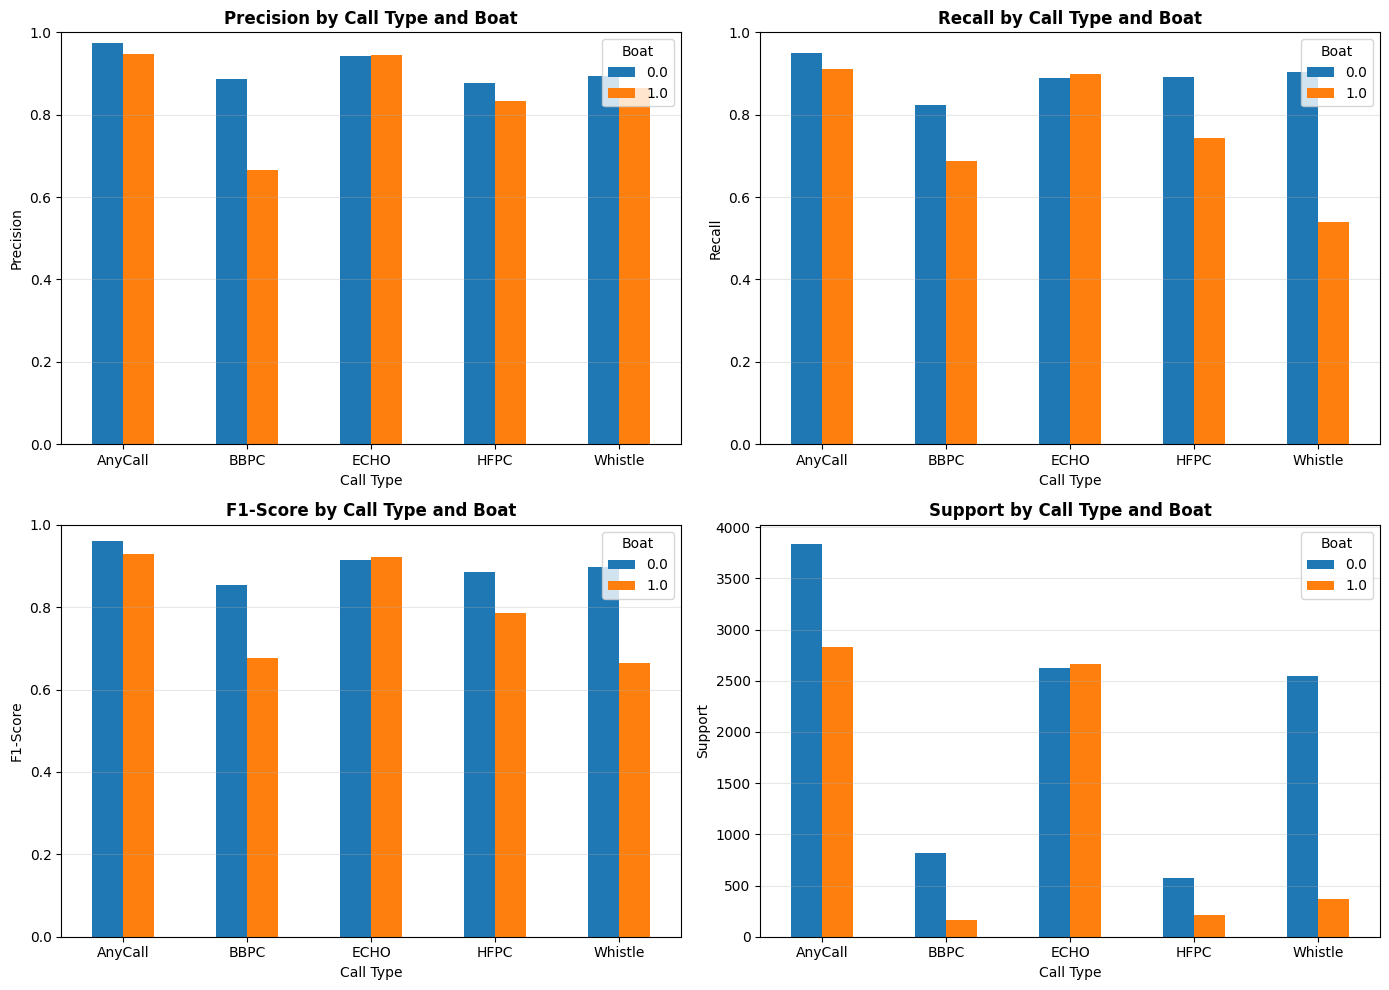

In [105]:




avg_by_context = create_average_metrics_dataframe(
    metrics_overall, metrics_by_context, group_name="Boat"
)
print_average_metrics(avg_by_context, "Boat")


# Create summary dataframes
summary_by_context = create_summary_dataframe(
    metrics_overall, metrics_by_context, call_types, group_name="Boat"
)

# Plot
fig_context = plot_metrics_comparison(
    summary_by_context, group_name="Boat", exclude_overall=True
)
plt.show()

In [106]:
avg_by_context

,Boat,Macro Avg Precision,Macro Avg Recall,Macro Avg F1,Micro Avg F1,False Alarm Rate,Samples Avg F1,n_samples
0,Overall,0.901609,0.867177,0.884013,0.913571,{},0.384850,15518
1,0.0,0.914402,0.891088,0.902303,0.921114,{},0.310409,11163
2,1.0,0.851135,0.756842,0.795740,0.900761,{},0.575662,4355


## False Alarm Rate

## looking at the errors spectrograms

In [107]:
test_predictions_df["ECHO_correct"] = test_predictions_df["ECHO_pred"] == test_predictions_df["ECHO_true"]
test_predictions_df["BBPC_correct"] = test_predictions_df["BBPC_pred"] == test_predictions_df["BBPC_true"]
test_predictions_df["HFPC_correct"] = test_predictions_df["HFPC_pred"] == test_predictions_df["HFPC_true"]
test_predictions_df["Whistle_correct"] = test_predictions_df["Whistle_pred"] == test_predictions_df["Whistle_true"]
test_predictions_df["AnyCall_correct"] = test_predictions_df["AnyCall_pred"] == test_predictions_df["AnyCall_true"]

In [80]:
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat_x,HydrophoneSensitivity_x,labeling_effort_x,original_filename_x,labeled_snippet_filename_x,AnyCall_pred,AnyCall_true,ECHO_correct,BBPC_correct,HFPC_correct,Whistle_correct,AnyCall_correct,Boat_y,HydrophoneSensitivity_y,labeling_effort_y,original_filename_y,labeled_snippet_filename_y,Begin Time (s)
0,BSM_20170724_10580300.pt,BSM,0.0,0.0,1.064708e-07,0.0,0.0,5.555425e-08,0.0,0.0,8.210722e-10,0.0,0.0,7.577163e-04,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,False,False,True,True,True,True,True,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN
1,BSM_20170724_12500100.pt,BSM,0.0,0.0,5.124426e-10,0.0,0.0,4.828254e-13,0.0,0.0,2.277526e-15,0.0,0.0,4.426653e-12,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,False,False,True,True,True,True,True,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN
2,BSM_20170724_13091179.pt,BSM,0.0,0.0,9.881670e-08,0.0,0.0,2.271912e-07,0.0,0.0,2.599865e-08,1.0,1.0,9.998454e-01,0,0.0,-172.7,irene_20min,NaN,NaN,True,True,True,True,True,True,True,0.0,-172.7,irene_20min,NaN,NaN,NaN
3,BSM_20170724_13182240.pt,BSM,1.0,1.0,9.999999e-01,0.0,0.0,9.292549e-09,0.0,0.0,2.737549e-11,0.0,0.0,2.100043e-07,0,0.0,-172.7,irene_20min,NaN,NaN,True,True,True,True,True,True,True,0.0,-172.7,irene_20min,NaN,NaN,NaN
4,BSM_20170724_13215300.pt,BSM,0.0,0.0,1.022840e-11,0.0,0.0,4.166788e-14,0.0,0.0,2.764440e-15,0.0,0.0,8.305502e-12,0,0.0,-172.7,old_abs_from_3s_snippets,NaN,NaN,False,False,True,True,True,True,True,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15513,RDL_20200828_18463981.pt,RDL,0.0,0.0,1.296506e-03,0.0,0.0,4.369019e-05,1.0,1.0,9.999999e-01,1.0,1.0,9.997057e-01,4,1.0,-176.5,irene_5min,NaN,NaN,True,True,True,True,True,True,True,1.0,-176.5,irene_5min,NaN,NaN,NaN
15514,RDL_20200828_18471243.pt,RDL,0.0,0.0,1.048050e-01,1.0,0.0,3.967041e-01,1.0,1.0,9.999752e-01,1.0,1.0,9.975997e-01,4,0.0,-176.5,irene_20min,NaN,NaN,True,True,True,True,False,True,True,0.0,-176.5,irene_20min,NaN,NaN,NaN
15515,RDL_20200828_18472532.pt,RDL,0.0,0.0,3.582016e-06,1.0,0.0,5.182538e-04,1.0,1.0,9.999506e-01,1.0,1.0,9.909115e-01,4,0.0,-176.5,irene_20min,NaN,NaN,True,True,True,True,False,True,True,0.0,-176.5,irene_20min,NaN,NaN,NaN
15516,RDL_20200829_13033400.pt,RDL,0.0,0.0,1.274915e-05,0.0,0.0,1.400412e-09,0.0,0.0,1.158168e-10,0.0,0.0,3.644869e-10,4,0.0,-176.5,irene_20min,NaN,NaN,False,False,True,True,True,True,True,0.0,-176.5,irene_20min,NaN,NaN,NaN


In [108]:
from data_preprocessing.spectrogram.spectrogram_generator import HYDROPHONE_SENSITIVITY, SpectrogramGenerator

spect_generator = SpectrogramGenerator(
        n_fft=2048,
        hop_length=int(2048/2),
        n_mels=64,
        fmin=200,
        sample_rate=192000, 
    )

In [109]:
test_predictions_df["Boat"].value_counts()

Boat
0.0    11163
1.0     4355
Name: count, dtype: int64

In [83]:
labels_df.columns

Index(['clip_filename', 'ECHO', 'BBPC', 'HFPC', 'Whistle', 'Call', 'Boat',
       'labeling_effort', 'DETAIL', 'Begin Time (s)', 'End Time (s)',
       'GROUNDTRUTH', 'Notes', 'original_filename', 'labeled_snippet_filename',
       'snippet_start_time', 'snippet_start_s', 'snippet_end_s', 'Site',
       'labeled_snippet_dir', 'HydrophoneModel', 'HydrophoneSensitivity',
       'clip_start_time', 'clip_end_time', 'DETAILS', 'boat_labeling_file',
       'boat_labeling_file_id', 'annotator', 'SnippetFilename', 'start_s',
       'end_s', 'ClipFilenamePt'],
      dtype='str')

In [32]:
test_predictions_df

,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,AnyCall_pred,AnyCall_true,ECHO_correct,BBPC_correct,HFPC_correct,Whistle_correct
0,BSM_20170724_10580300.pt,BSM,0.0,0.0,1.064708e-07,0.0,0.0,5.555425e-08,0.0,0.0,8.210722e-10,0.0,0.0,7.577163e-04,0,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,False,False,True,True,True,True
1,BSM_20170724_12500100.pt,BSM,0.0,0.0,5.124426e-10,0.0,0.0,4.828254e-13,0.0,0.0,2.277526e-15,0.0,0.0,4.426653e-12,0,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,False,False,True,True,True,True
2,BSM_20170724_13091179.pt,BSM,0.0,0.0,9.881670e-08,0.0,0.0,2.271912e-07,0.0,0.0,2.599865e-08,1.0,1.0,9.998454e-01,0,0.0,-172.7,irene_20min,NaN,NaN,True,True,True,True,True,True
3,BSM_20170724_13182240.pt,BSM,1.0,1.0,9.999999e-01,0.0,0.0,9.292549e-09,0.0,0.0,2.737549e-11,0.0,0.0,2.100043e-07,0,0.0,-172.7,irene_20min,NaN,NaN,True,True,True,True,True,True
4,BSM_20170724_13215300.pt,BSM,0.0,0.0,1.022840e-11,0.0,0.0,4.166788e-14,0.0,0.0,2.764440e-15,0.0,0.0,8.305502e-12,0,NaN,-172.7,old_abs_from_3s_snippets,NaN,NaN,False,False,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15513,RDL_20200828_18463981.pt,RDL,0.0,0.0,1.296506e-03,0.0,0.0,4.369019e-05,1.0,1.0,9.999999e-01,1.0,1.0,9.997057e-01,4,1.0,-176.5,irene_5min,NaN,NaN,True,True,True,True,True,True
15514,RDL_20200828_18471243.pt,RDL,0.0,0.0,1.048050e-01,1.0,0.0,3.967041e-01,1.0,1.0,9.999752e-01,1.0,1.0,9.975997e-01,4,0.0,-176.5,irene_20min,NaN,NaN,True,True,True,True,False,True
15515,RDL_20200828_18472532.pt,RDL,0.0,0.0,3.582016e-06,1.0,0.0,5.182538e-04,1.0,1.0,9.999506e-01,1.0,1.0,9.909115e-01,4,0.0,-176.5,irene_20min,NaN,NaN,True,True,True,True,False,True
15516,RDL_20200829_13033400.pt,RDL,0.0,0.0,1.274915e-05,0.0,0.0,1.400412e-09,0.0,0.0,1.158168e-10,0.0,0.0,3.644869e-10,4,0.0,-176.5,irene_20min,NaN,NaN,False,False,True,True,True,True


In [57]:
sample = test_predictions_df[(test_predictions_df["Boat"] == 1)& (test_predictions_df["AnyCall_correct"] == False) & (test_predictions_df["AnyCall_true"] == 0)]
sample


,Filename,Site,ECHO_true,ECHO_pred,ECHO_probs,HFPC_true,HFPC_pred,HFPC_probs,BBPC_true,BBPC_pred,BBPC_probs,Whistle_true,Whistle_pred,Whistle_probs,Fold,Boat,HydrophoneSensitivity,labeling_effort,original_filename,labeled_snippet_filename,AnyCall_pred,AnyCall_true,ECHO_correct,BBPC_correct,HFPC_correct,Whistle_correct,AnyCall_correct
90,BSM_20170725_06100200.pt,BSM,0.0,1.0,0.667094,0.0,0.0,7.072496e-07,0.0,0.0,7.595362e-07,0.0,0.0,9.481690e-08,0,1.0,-172.7,evaluation_v2,201359382.170725053002.wav,201359382.170725060901.snippet.wav,True,False,False,True,True,True,False
130,BSM_20170725_06104200.pt,BSM,0.0,0.0,0.005344,0.0,0.0,4.688152e-04,0.0,1.0,8.049797e-01,0.0,0.0,5.496058e-06,0,1.0,-172.7,evaluation_v2,201359382.170725053002.wav,201359382.170725060901.snippet.wav,True,False,True,False,True,True,False
2258,CAC_20210718_08544200.pt,CAC,0.0,1.0,0.999955,0.0,0.0,1.040691e-06,0.0,0.0,1.176850e-06,0.0,0.0,3.344447e-06,0,1.0,-172.7,evaluation_v2,201359382.210718075958.wav,201359382.210718085424.snippet.wav,True,False,False,True,True,True,False
2259,CAC_20210718_08544300.pt,CAC,0.0,1.0,0.999995,0.0,0.0,3.871297e-08,0.0,0.0,1.136150e-07,0.0,0.0,2.766364e-04,0,1.0,-172.7,evaluation_v2,201359382.210718075958.wav,201359382.210718085424.snippet.wav,True,False,False,True,True,True,False
2795,KAM_20200730_13285000.pt,KAM,0.0,0.0,0.000018,0.0,0.0,1.383911e-03,0.0,0.0,9.124854e-08,0.0,1.0,6.904239e-01,0,1.0,-175.7,evaluation_v2,5725.200730125955.wav,5725.200730132804.snippet.wav,True,False,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12459,BSM_20170724_10401300.pt,BSM,0.0,1.0,0.690214,0.0,0.0,1.680618e-04,0.0,0.0,8.014599e-05,0.0,0.0,4.659877e-01,4,1.0,-172.7,evaluation_v2,201359382.170724103002.wav,201359382.170724103928.snippet.wav,True,False,False,True,True,True,False
12520,BSM_20170724_10411400.pt,BSM,0.0,0.0,0.002372,0.0,0.0,3.447759e-06,0.0,1.0,5.487041e-01,0.0,0.0,1.811925e-03,4,1.0,-172.7,evaluation_v2,201359382.170724103002.wav,201359382.170724103928.snippet.wav,True,False,True,False,True,True,False
14862,KAM_20200731_14040400.pt,KAM,0.0,1.0,0.508357,0.0,0.0,2.223405e-07,0.0,0.0,4.435524e-05,0.0,0.0,3.015014e-07,4,1.0,-175.7,evaluation_v2,5725.200731135954.wav,5725.200731140339.snippet.wav,True,False,False,True,True,True,False
15097,KAM_20200731_14163600.pt,KAM,0.0,1.0,0.802081,0.0,0.0,4.174427e-04,0.0,0.0,1.160099e-05,0.0,0.0,4.411580e-05,4,1.0,-175.7,evaluation_v2,5725.200731135954.wav,5725.200731141523.snippet.wav,True,False,False,True,True,True,False


0/170
nan
irene_20min
740    NaN
Name: labeled_snippet_filename, dtype: str
BSM_20170724_13463240.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


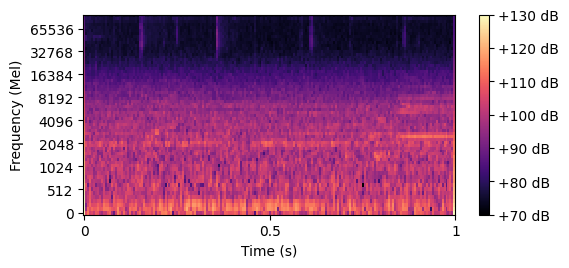

1/170
15.0
evaluation_v1
11920    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19192000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


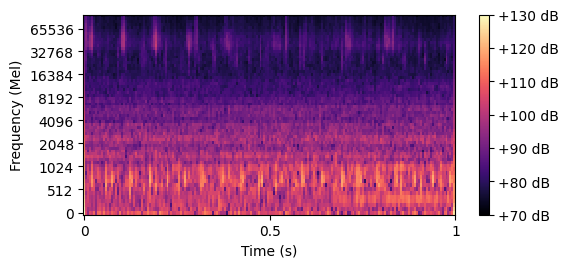

2/170
16.0
evaluation_v1
11921    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19192100.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


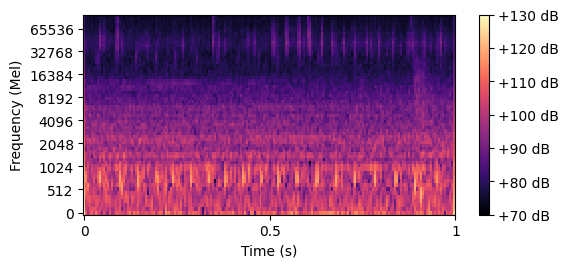

3/170
20.0
evaluation_v1
11925    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19192500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


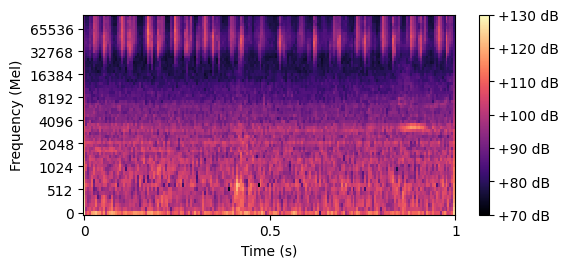

4/170
33.0
evaluation_v1
11938    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19193800.wav
ECHO: true 1 vs pred 1   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


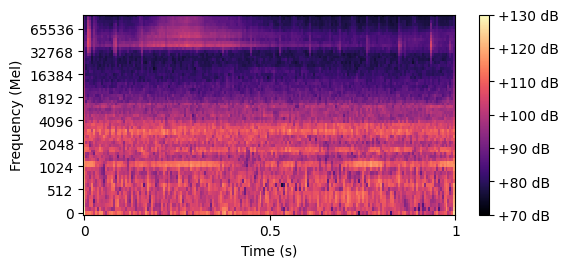

5/170
34.0
evaluation_v1
11939    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19193900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


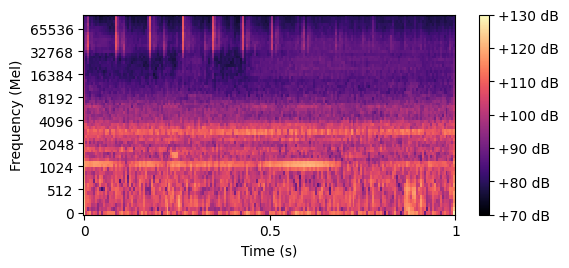

6/170
36.0
evaluation_v1
11941    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19194100.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


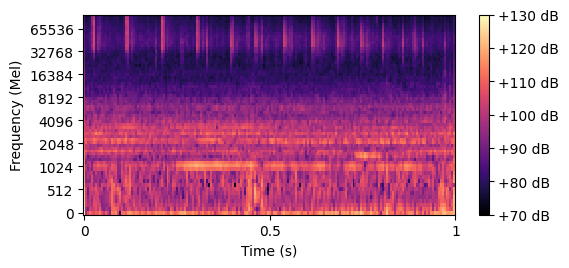

7/170
112.0
evaluation_v1
12017    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19205700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


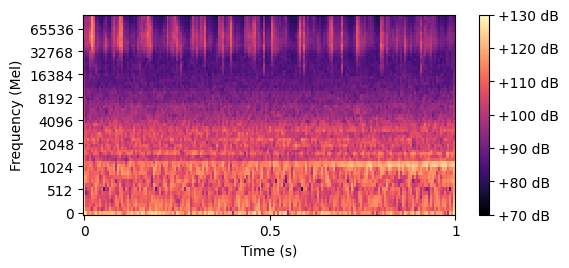

8/170
142.0
evaluation_v1
12047    5725.200726191905.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19212700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


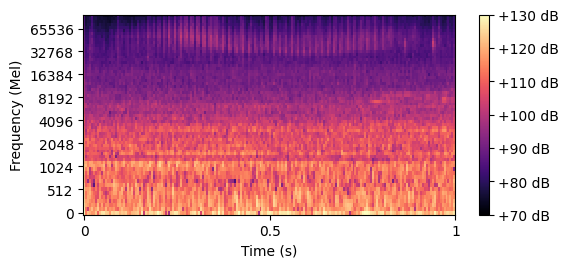

9/170
478.0
evaluation_v1
766    201359382.170724133858.snippet.wav
Name: labeled_snippet_filename, dtype: str
BSM_20170724_13465600.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


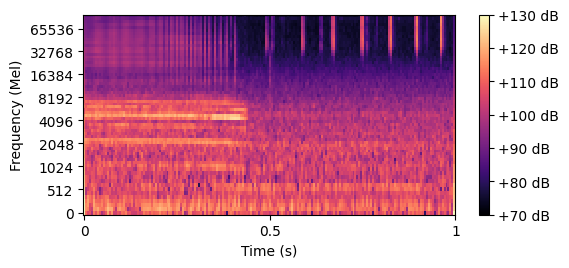

10/170
1.0
evaluation_v2
11034    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13290600.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


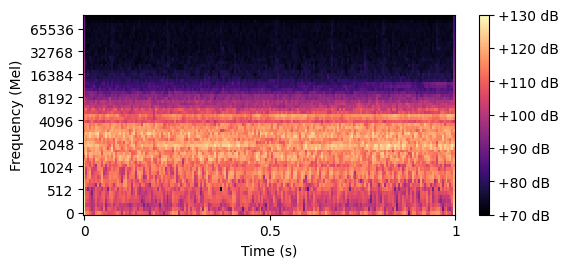

11/170
2.0
evaluation_v2
11035    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13290700.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


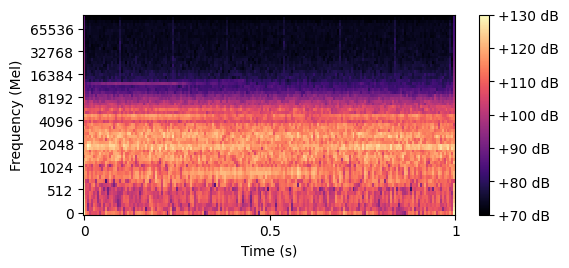

12/170
8.0
evaluation_v2
11041    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13291300.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


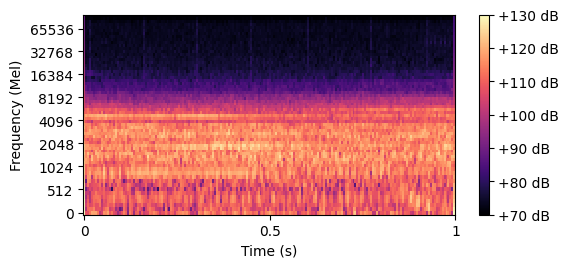

13/170
26.0
evaluation_v2
11059    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13293100.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


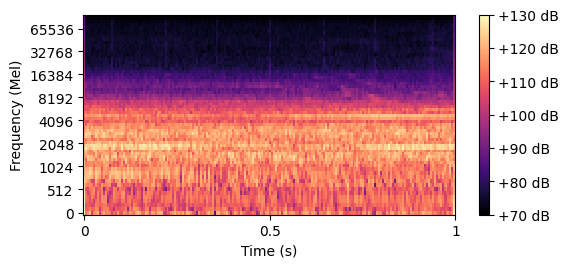

14/170
36.0
evaluation_v2
11069    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13294100.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


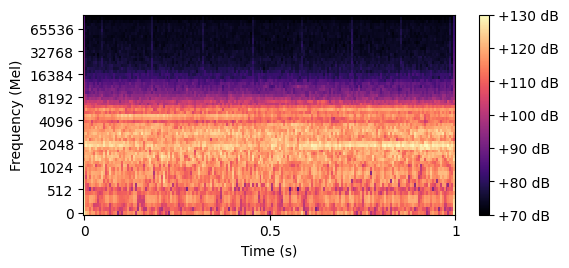

15/170
38.0
evaluation_v2
11071    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13294300.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


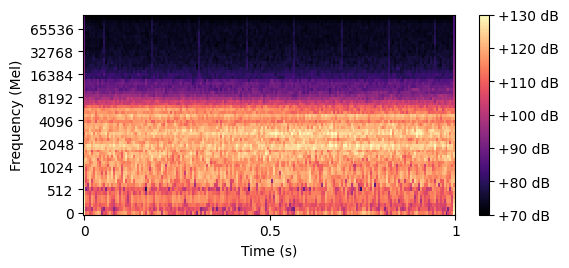

16/170
39.0
evaluation_v2
11072    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13294400.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


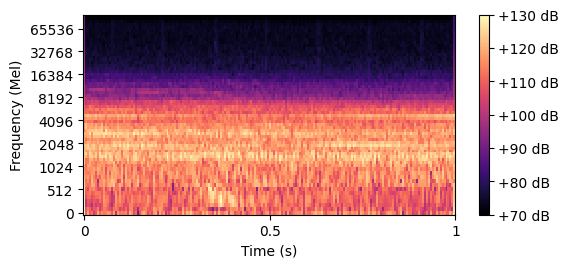

17/170
79.0
evaluation_v2
11112    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13302400.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


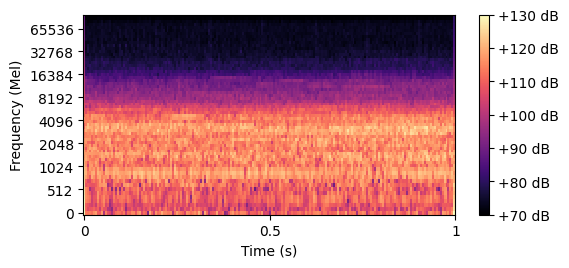

18/170
80.0
evaluation_v2
11113    201359382.210804132905.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210804_13302500.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


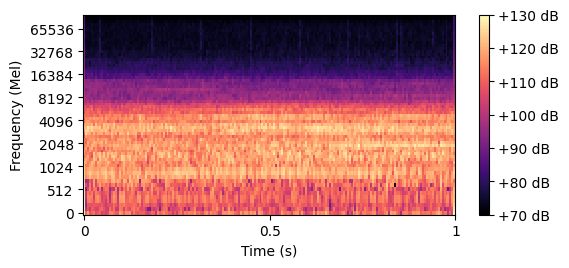

19/170
181.0
evaluation_v1
12440    5725.200726195504.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19580500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


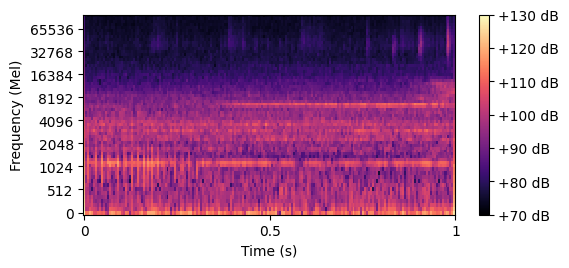

20/170
205.0
evaluation_v1
12464    5725.200726195504.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19582900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


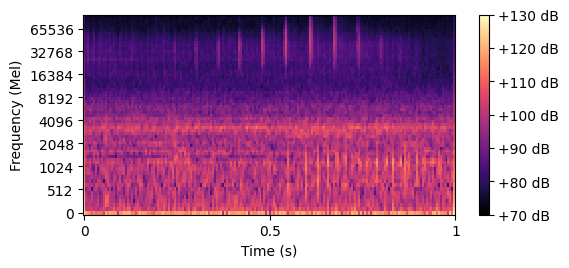

21/170
206.0
evaluation_v1
12465    5725.200726195504.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19583000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


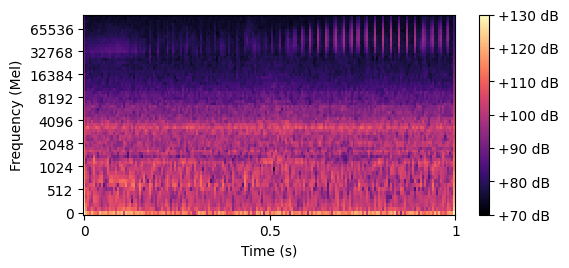

22/170
215.0
evaluation_v1
12474    5725.200726195504.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19583900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


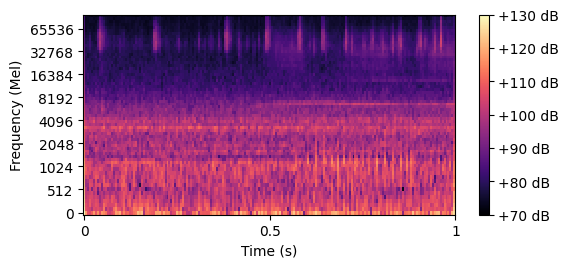

23/170
238.0
evaluation_v1
12497    5725.200726195504.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200726_19590200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


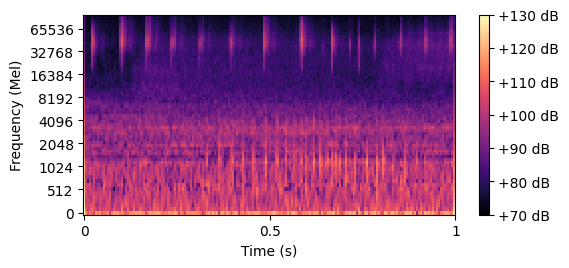

24/170
87.0
evaluation_v2
12723    5725.200729113050.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200729_11321700.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


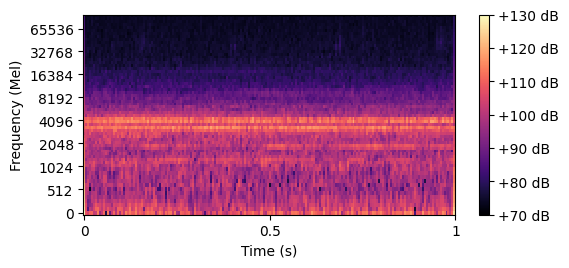

25/170
nan
irene_20min
14409    NaN
Name: labeled_snippet_filename, dtype: str
KAM_20210720_14424383.wav
ECHO: true 0 vs pred 0   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


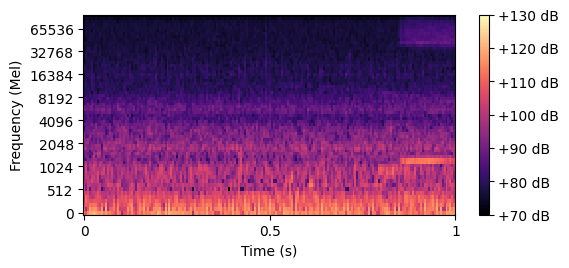

26/170
nan
irene_5min
741    NaN
Name: labeled_snippet_filename, dtype: str
BSM_20170724_13463270.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


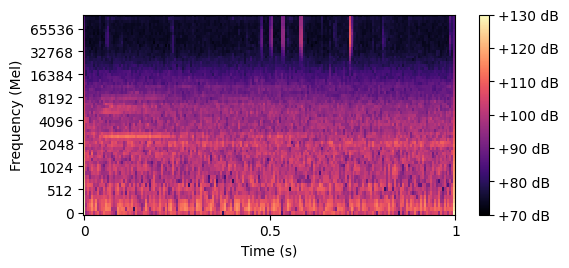

27/170
115.0
evaluation_v2
12991    5725.200730122420.snippet.wav
Name: labeled_snippet_filename, dtype: str
KAM_20200730_12261500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


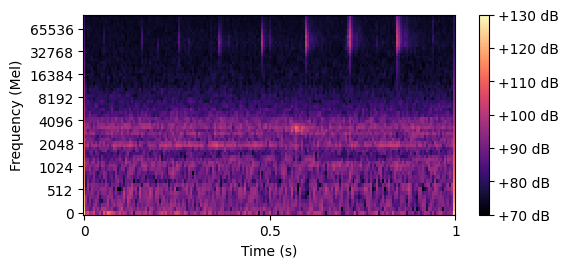

28/170
2.0
evaluation_v1
8516    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08305500.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


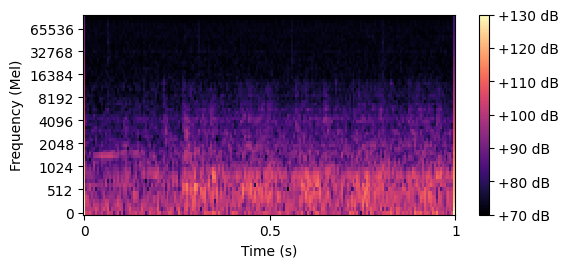

29/170
94.0
evaluation_v1
8611    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08322700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


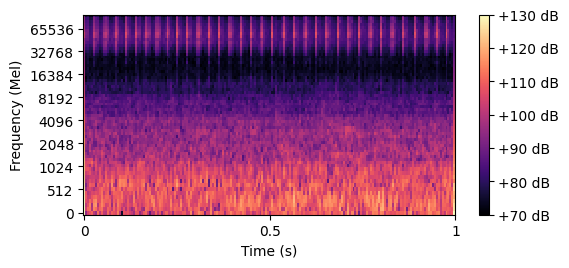

30/170
96.0
evaluation_v1
8613    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08322900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


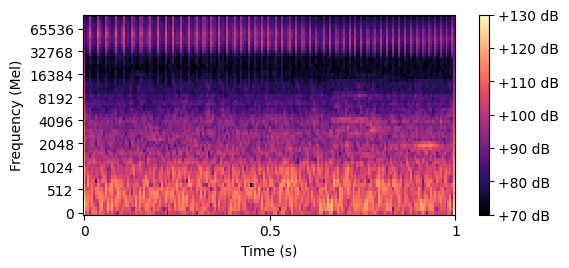

31/170
97.0
evaluation_v1
8614    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08323000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


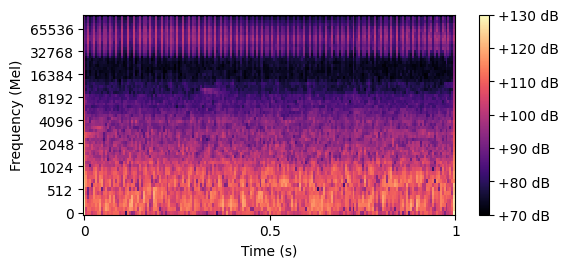

32/170
110.0
evaluation_v1
8627    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08324300.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


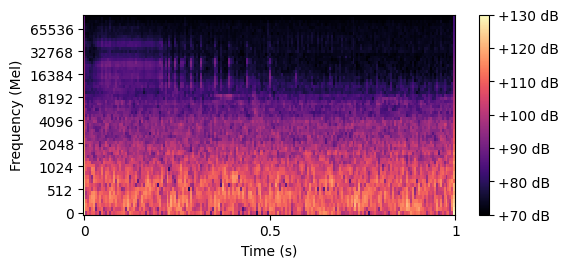

33/170
120.0
evaluation_v1
8637    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08325300.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


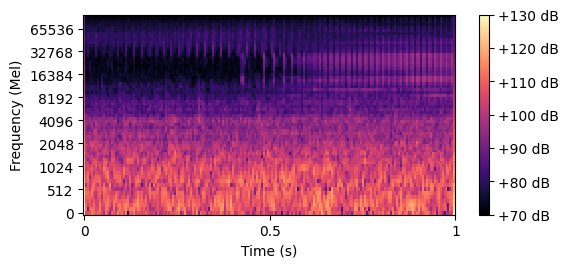

34/170
122.0
evaluation_v1
8639    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08325500.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


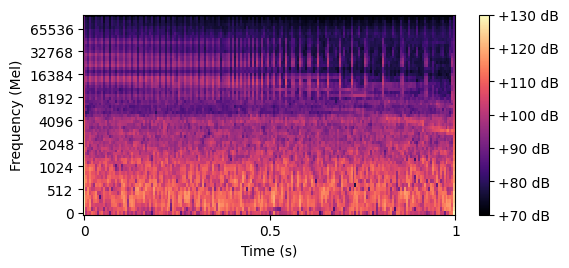

35/170
124.0
evaluation_v1
8641    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08325700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


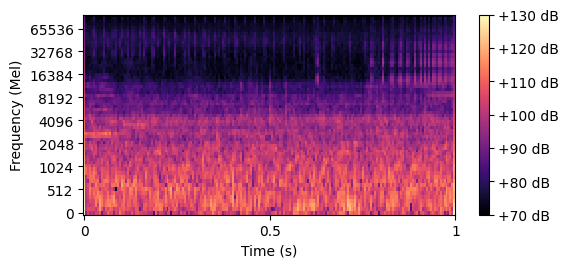

36/170
126.0
evaluation_v1
8643    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08325900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


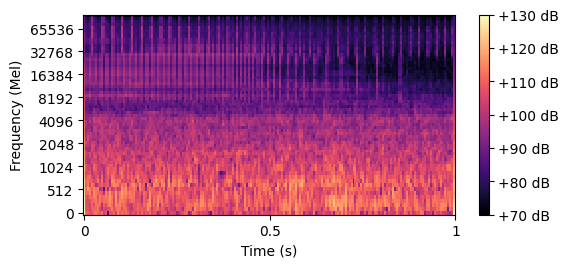

37/170
128.0
evaluation_v1
8645    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08330100.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


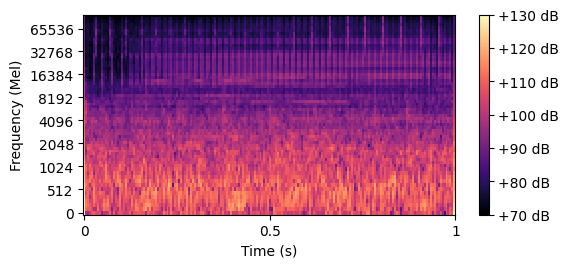

38/170
129.0
evaluation_v1
8646    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08330200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


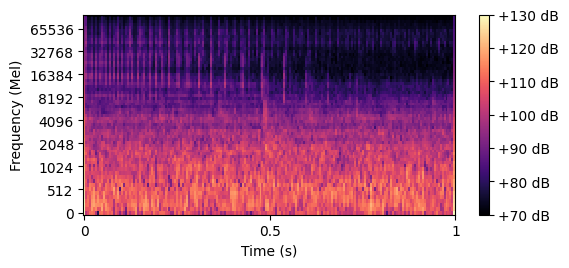

39/170
132.0
evaluation_v1
8649    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08330500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


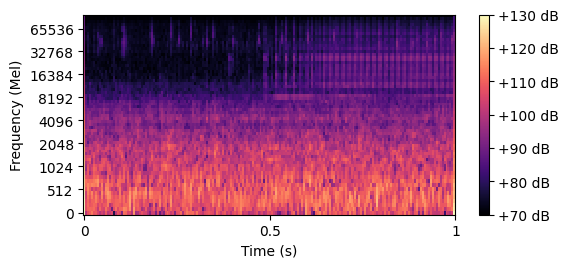

40/170
133.0
evaluation_v1
8650    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08330600.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


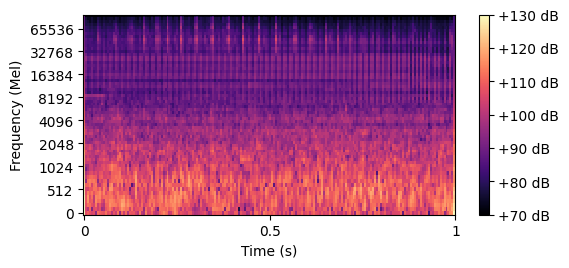

41/170
134.0
evaluation_v1
8651    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08330700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 1   Whistle: true 1 vs pred 0


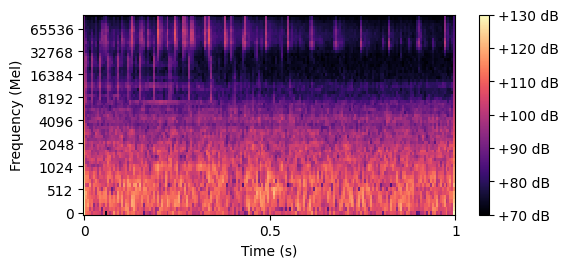

42/170
139.0
evaluation_v1
8656    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08331200.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


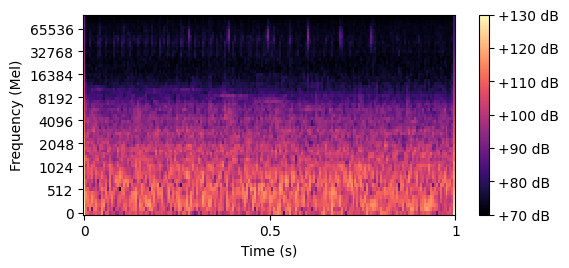

43/170
166.0
evaluation_v1
8686    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08333900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


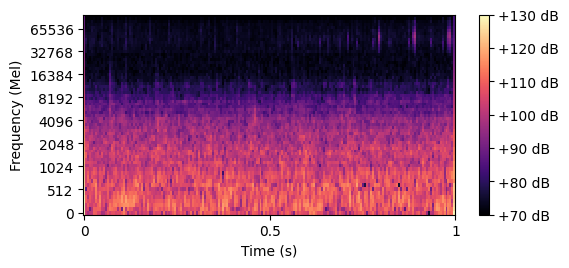

44/170
167.0
evaluation_v1
8687    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08334000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


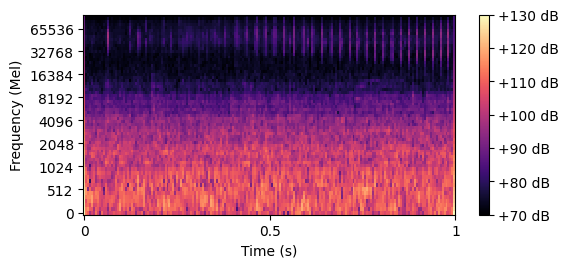

45/170
170.0
evaluation_v1
8690    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08334300.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


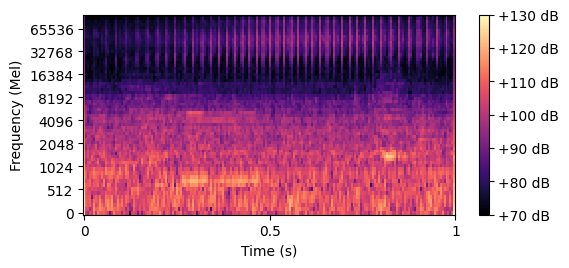

46/170
172.0
evaluation_v1
8692    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08334500.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


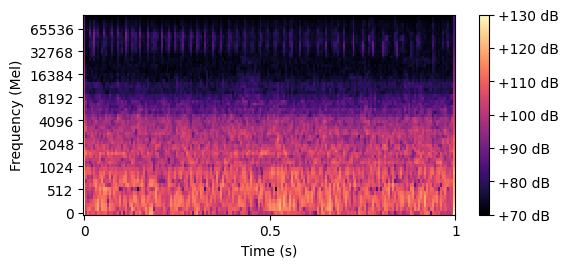

47/170
174.0
evaluation_v1
8694    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08334700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


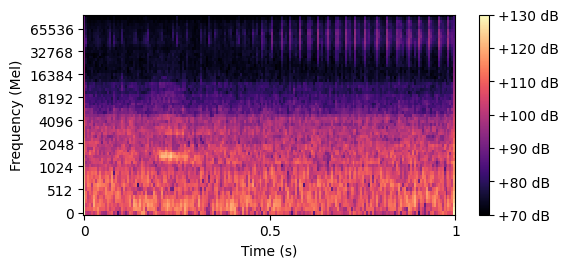

48/170
175.0
evaluation_v1
8695    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08334800.wav
ECHO: true 1 vs pred 1   HFPC: true 1 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


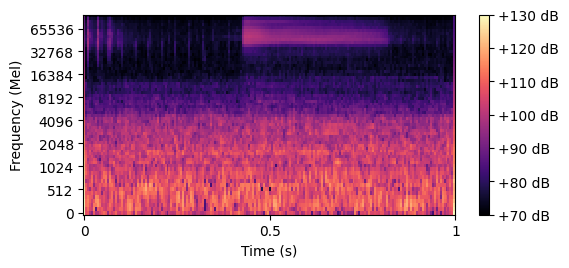

49/170
176.0
evaluation_v1
8696    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08334900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 1 vs pred 0   Whistle: true 1 vs pred 0


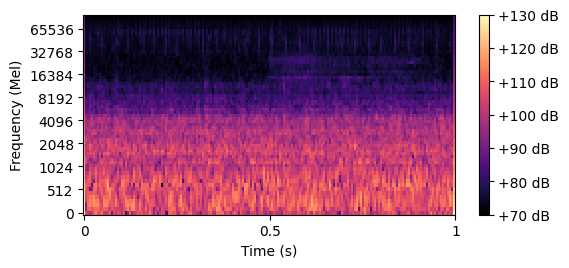

50/170
195.0
evaluation_v1
8715    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08340800.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


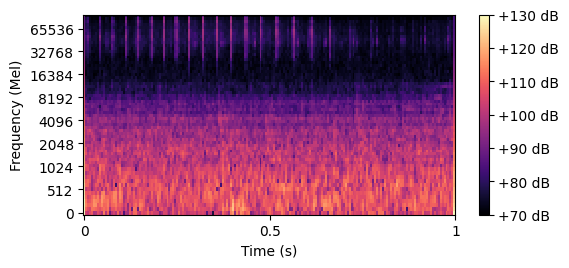

51/170
196.0
evaluation_v1
8716    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08340900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


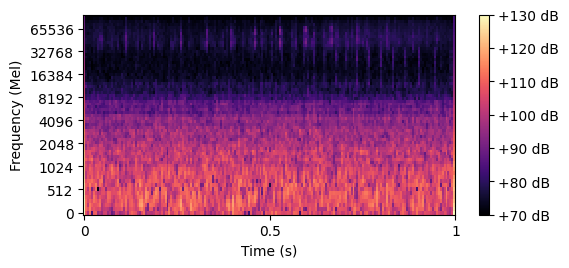

52/170
214.0
evaluation_v1
8734    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08342700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


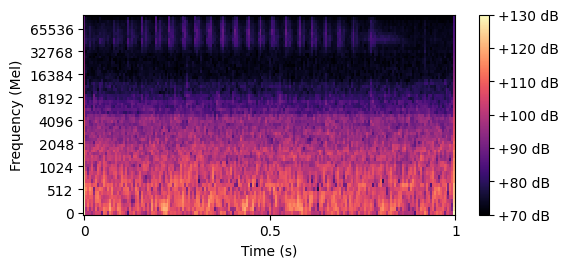

53/170
215.0
evaluation_v1
8735    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08342800.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


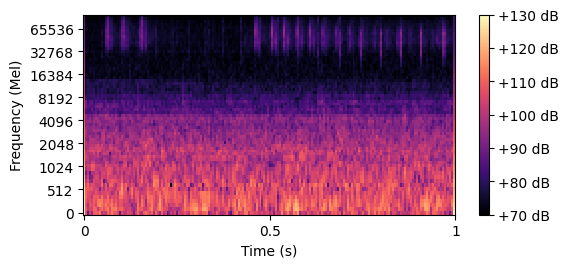

54/170
244.0
evaluation_v1
8764    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08345700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


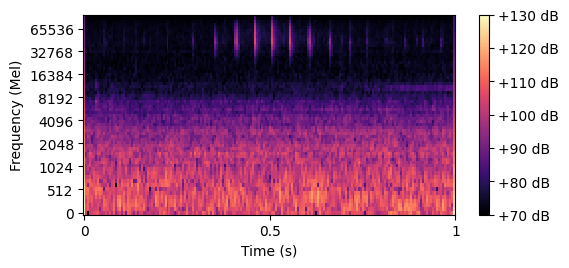

55/170
245.0
evaluation_v1
8765    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08345800.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


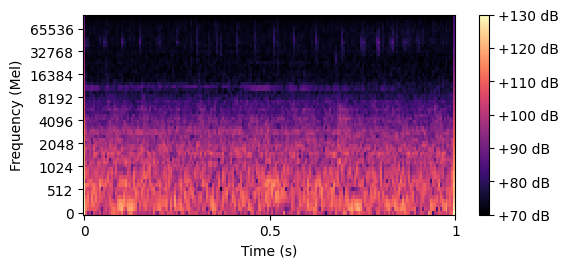

56/170
258.0
evaluation_v1
8778    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08351100.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


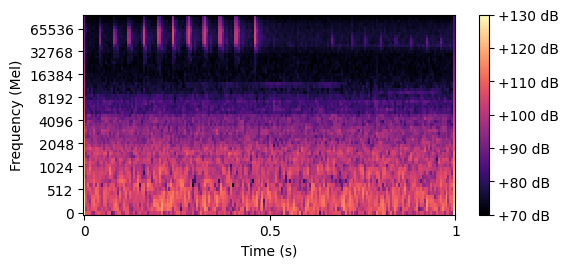

57/170
259.0
evaluation_v1
8779    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08351200.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


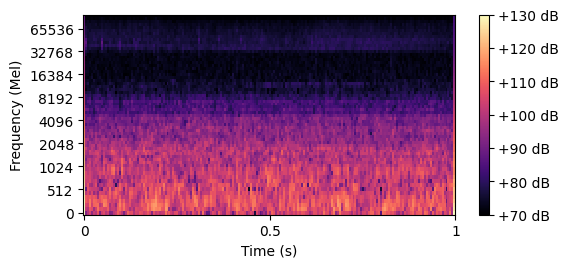

58/170
260.0
evaluation_v1
8780    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08351300.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


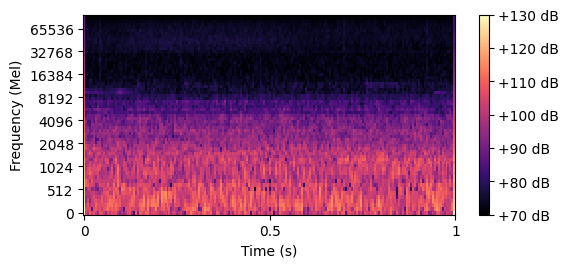

59/170
261.0
evaluation_v1
8781    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08351400.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


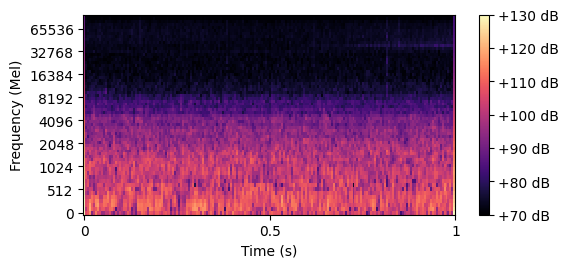

60/170
262.0
evaluation_v1
8782    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08351500.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 1   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


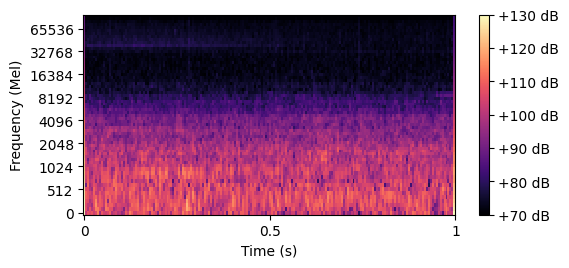

61/170
263.0
evaluation_v1
8783    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08351600.wav
ECHO: true 0 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


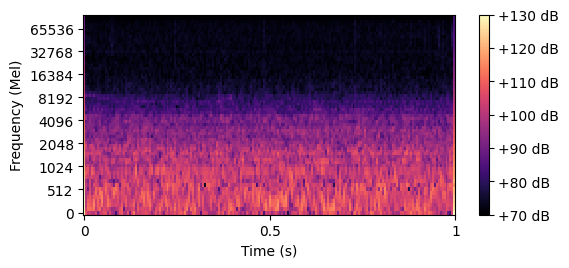

62/170
267.0
evaluation_v1
8787    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08352000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


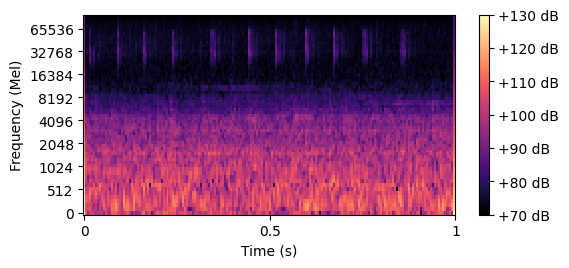

63/170
268.0
evaluation_v1
8788    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08352100.wav
ECHO: true 1 vs pred 0   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


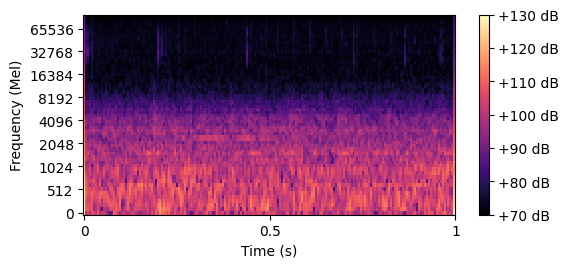

64/170
294.0
evaluation_v1
8814    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08354700.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


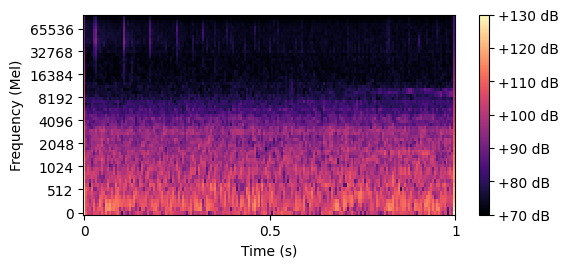

65/170
306.0
evaluation_v1
8826    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08355900.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


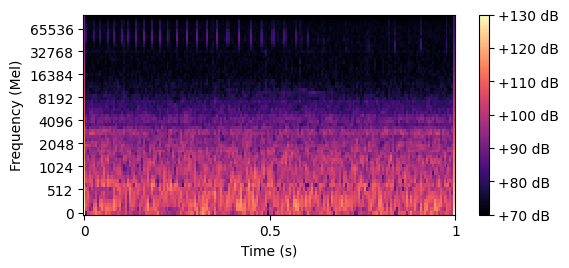

66/170
307.0
evaluation_v1
8827    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08360000.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


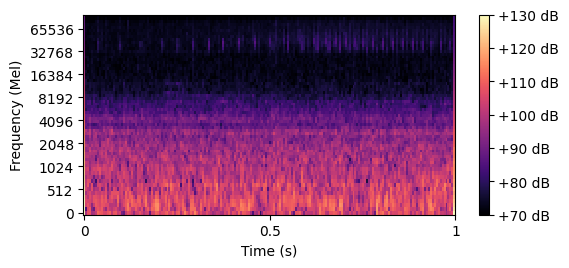

67/170
310.0
evaluation_v1
8830    201359382.210714083053.snippet.wav
Name: labeled_snippet_filename, dtype: str
CAC_20210714_08360300.wav
ECHO: true 1 vs pred 1   HFPC: true 0 vs pred 0   BBPC: true 0 vs pred 0   Whistle: true 1 vs pred 0


In [ ]:

DATA_DIRECTORY = "../../data/"

wavs_folder = DATA_DIRECTORY + "Verified_Dataset/clip_wavs/"

# sample = labels_df[labels_df["Notes"].notna()]
# sample = labels_df[labels_df["clip_filename"] == "CAC_20210714_08342600.wav"]
# boat_df = test_predictions_df[test_predictions_df["Boat"] == 1]
# sample = boat_df[boat_df["Whistle_correct"] == False].sample(30)

# sample = test_predictions_df[(test_predictions_df["labeled_snippet_filename"] == "5725.200726191905.snippet.wav")& (test_predictions_df["Whistle"] == 1)].sample(10)
sample = test_predictions_df[(test_predictions_df["Boat"] == 1)& (test_predictions_df["Whistle_correct"] == False) & (test_predictions_df["Whistle_true"] == 1)]

# sample = test_predictions_df[test_predictions_df["Filename"] == "RDL_20200727_13012408.pt"]
count=0
for index, row in sample.iterrows():  
    print(f"{count}/{len(sample)}")
    count+=1
    print(row["Begin Time (s)"])
    wav_filename = row["Filename"].replace(".pt", ".wav")
    print(row["labeling_effort"])
    # print(row["anotator"])
    print(labels_df[labels_df["clip_filename"] ==wav_filename]["labeled_snippet_filename"])  
    
    title = f"{wav_filename}\n"

    for label in ["ECHO", "HFPC", "BBPC", "Whistle"]:
        true_val = row[f"{label}_true"] if f"{label}_true" in row else row.get(label, None)
        pred_val = row[f"{label}_pred"] if f"{label}_pred" in row else None
        title += f"{label}: true {int(true_val)} vs pred {int(pred_val)}   "
    title = title.strip()
    print(title)
    # print("Boat:", row["Boat"])

    file_path = wavs_folder + wav_filename

    audio, sr, original_sr = spect_generator.load_audio(file_path)


    power_spect = spect_generator.compute_mel_power_spect(audio)

    
    dB_spect = spect_generator.power_to_db(power_spect, hydrophone_sensitivity=row["HydrophoneSensitivity"])
  

    spect_generator.plot_spect(dB_spect, figsize=(6,2.6), title="", tick_interval=0.5, colorbar_range=(70, 130), transparent_background=True)

    # dB_spect_normalized = spect_generator.min_max_normalization(dB_spect)
    
    # dB_spect_resized = spect_generator.resize_spect(dB_spect_normalized, img_shape=(244,244))

    